## TEST Finetune on random images

In [14]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
import os
import requests

import torch
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

# check whether run in Colab
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip3 install timm==0.4.5  # 0.3.2 does not work in Colab
    !git clone https://github.com/facebookresearch/mae.git
    sys.path.append('./mae')
else:
    sys.path.append('..')
import models_vit

from pytorch_grad_cam import GradCAM,HiResCAM,ScoreCAM,GradCAMPlusPlus,AblationCAM,XGradCAM,EigenCAM,FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import transforms
import json
from pathlib import Path
from collections import OrderedDict

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## UTILITY FUNCTIONS

In [37]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def prepare_model(chkpt_dir, arch='mae_vit_large_patch16'):
    # build model
    model = models_vit.__dict__[arch](
        num_classes=2,
        global_pool=False,
    )
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu')
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def prepare_model_special(chkpt_dir, arch='vit_large_patch16'):
    # build model
    model = models_vit.__dict__[arch](
        num_classes=2,
        global_pool=False,
    )
    # load model
    checkpoint = torch.load(chkpt_dir, map_location='cpu',weights_only=True)
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    return model

def run_one_image(img, model):
    x = torch.tensor(img)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    y = model(x.float())
    return y 

def read_json(fname):
    fname = Path(fname)
    with fname.open('rt') as handle:
        return json.load(handle, object_hook=OrderedDict)

In [5]:
#################################################
chkpt_dir = './finetune3/best_model.pth'
model_mae_classif = prepare_model(chkpt_dir, 'vit_large_patch16')

<All keys matched successfully>


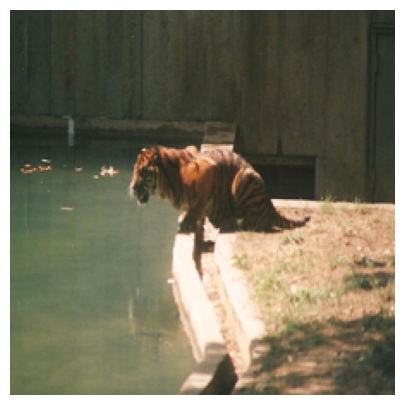

In [7]:
img_path = "../../data/cat_dog/test/cat/75.jpg"
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.

assert img_float.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_float - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [8]:
result = run_one_image(img_tsf, model_mae_classif)
# Optionally compute probabilities
probabilities = torch.softmax(result, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['cat', 'dog']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)


Probabilities: tensor([[0.9533, 0.0467]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['cat']


## GRAD CAM CHECKING

In [16]:
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1 :  , :].reshape(tensor.size(0),
        height, width, tensor.size(2))

    # Bring the channels to the first dimension,
    # like in CNNs.
    result = result.transpose(2, 3).transpose(1, 2)
    return result

trsfm = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(), # convert between 0 and 1
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

        ])


torch.Size([3, 224, 224])


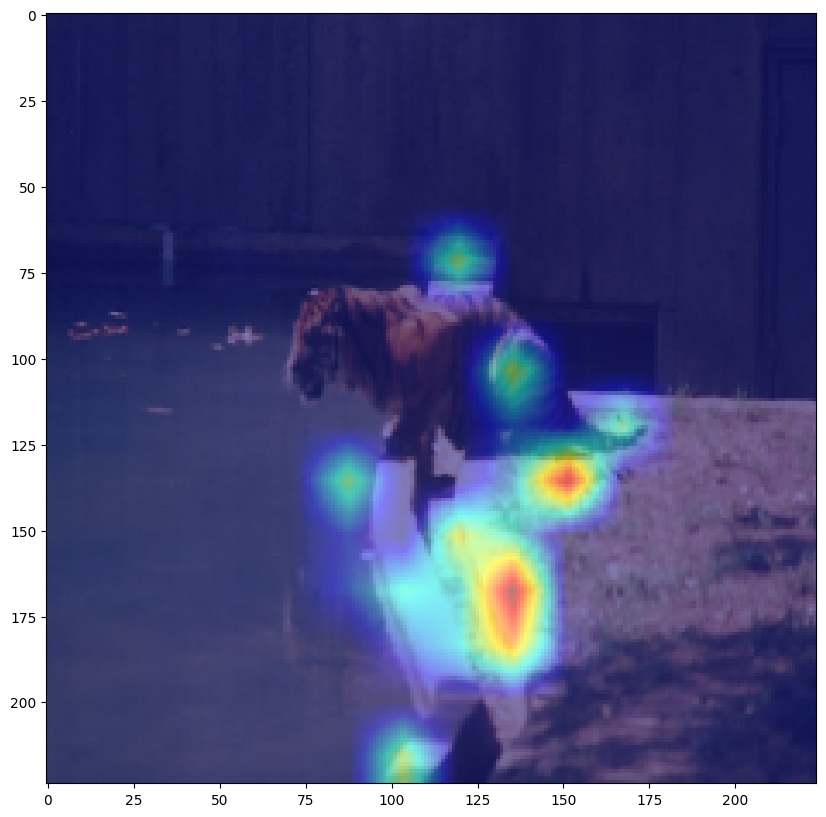

In [37]:
#img_torch = torch.from_numpy(img_float)
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif.blocks[-1].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam = GradCAM(model=model_mae_classif,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)



plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
plt.imshow(visualization)

## RAILSEM TEST FROM HERE

In [38]:
#################################################
#chkpt_dir_railsem = './finetune/finetune_railsem4_balanced_10000/best_model.pth'
chkpt_dir_railsem_nomask = './finetune/finetune_railsem4_balanced_10000/best_model.pth'
chkpt_dir_railsem_mask = './finetune/finetune_testold/best_model.pth'
chkpt_dir_vit_users_median = './finetune/finetune_VIT_Users_2vsall/best_model.pth'
chkpt_dir_vit_classif = '../thesis1/saved/Tab2/fold2/models/median_UsersVitClassif_Users_2vsall/median_UsersVitClassif_Users_2vsall/model_best.pth'
model_mae_classif_railsem_mask = prepare_model(chkpt_dir_railsem_mask,'vit_base_patch16')
model_mae_classif_railsem_nomask = prepare_model(chkpt_dir_railsem_nomask, 'vit_base_patch16')
model_mae_classif_vit_users_median = prepare_model(chkpt_dir_vit_users_median,'vit_base_patch16')
model_mae_classif_vit_classif = prepare_model_special(chkpt_dir_vit_classif,'vit_base_patch16')


<All keys matched successfully>
<All keys matched successfully>
<All keys matched successfully>


UnpicklingError: Weights only load failed. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution.Do it only if you get the file from a trusted source. WeightsUnpickler error: Unsupported class parse_config.ConfigParser

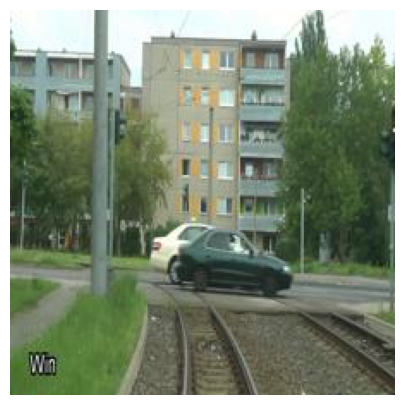

In [33]:
#img_path = "../../data/images/2vsall/test/risky/rs00184.jpg" ##RAILSEM19 TRAINING
img_path = "../../data/images/2vsall_bl_2/test/risky/rs07227.jpg"#railsem balanced
#img_path = "../../data/images/rs19_224/rs00202.jpg" ##RAILSEM19 ALL
#img_path="../../data/cat_dog/test/cat/94.jpg" ##CATDOG
#img_path = "../../data/simulator/synthetic/3_forest/images/8.png" ##SIMULATOR
img_true= Image.open(img_path)
img_resized = img_true.resize((224, 224))
img_float = np.array(img_resized) / 255.
img_jpg = img_float[:,:,:3]

assert img_jpg.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img_jpg - imagenet_mean
img_tsf = img / imagenet_std

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img_tsf))

In [34]:
result_nomask = run_one_image(img_tsf, model_mae_classif_railsem_nomask)
#result_mask = run_one_image(img_tsf,model_mae_classif_railsem_mask)
result_mask = run_one_image(img_tsf,model_mae_classif_vit_users_median)
# Optionally compute probabilities

## Here test the nomask
probabilities = torch.softmax(result_nomask, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result_nomask, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['risky', 'safe']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)

##Here test the masked
probabilities = torch.softmax(result_mask, dim=1)
print("Probabilities:", probabilities)

# Get the indices of the max logits
predicted_class_indices = torch.argmax(result_mask, dim=1)
print("Predicted class indices:", predicted_class_indices)

# Assuming you know your class labels
class_labels = ['risky', 'safe']
predicted_classes = [class_labels[idx] for idx in predicted_class_indices]
print("Predicted classes:", predicted_classes)

Probabilities: tensor([[0.9595, 0.0405]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['risky']
Probabilities: tensor([[0.8556, 0.1444]], grad_fn=<SoftmaxBackward0>)
Predicted class indices: tensor([0])
Predicted classes: ['risky']


### Grad cam checking

torch.Size([3, 224, 224])


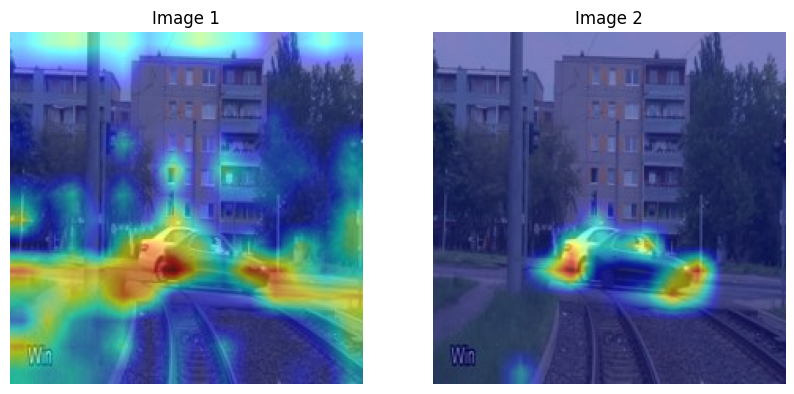

In [35]:
#img_torch = torch.from_numpy(img_float)
selecthead = -1
img_transformed = trsfm(img_true)
print(img_transformed.shape)
input_image = img_transformed.unsqueeze(0)

#input_tensor = input_image.to(device)
target_layers = [model_mae_classif_railsem_nomask.blocks[selecthead].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam1 = GradCAM(model=model_mae_classif_railsem_nomask,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

#empty image for test purpose
vide = np.zeros((224,224,3))
# Permute the dimensions to change the order
tensor_permuted = img_transformed.permute(1, 2, 0)
tensor_permuted_float = tensor_permuted.float()
# Scale values between 0 and 1
tensor_permuted_float = tensor_permuted_float / tensor_permuted_float.max()
# Convert the tensor to a NumPy array
numpy_array = tensor_permuted_float.numpy()

#transpose numpy_array to image original look
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_transposed = tensor_permuted* std + mean
img_transposed = np.clip(img_transposed,0,1)

grayscale_cam = cam1(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]

visualization1 = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)

target_layers = [model_mae_classif_vit_users_median.blocks[selecthead].norm1]
#target_layers = [block.norm1 for block in model.vit_model.blocks]
cam2 = GradCAM(model=model_mae_classif_vit_users_median,target_layers=target_layers,reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(0)]

grayscale_cam = cam2(input_tensor=input_image,targets=targets)
grayscale_cam = grayscale_cam[0,:]
visualization2 = show_cam_on_image(img_transposed.numpy(),grayscale_cam,use_rgb=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 10))

# Display the first image
axes[0].imshow(visualization1)
axes[0].axis("off")  # Hide axes
axes[0].set_title("Image 1")

# Display the second image
axes[1].imshow(visualization2)
axes[1].axis("off")  # Hide axes
axes[1].set_title("Image 2")

# Show the figure
plt.show()

## INVESTIGATION SANDBOX
### DIRTY CODE

In [17]:
# Add this at the top of your notebook or script
import sys
import types
sys.path.append('../thesis1/')
from parse_config import ConfigParser
import model.model as module_arch
chkpt_config_path_users_median = '../thesis1/config/EXPVISAPP2/Tab2/fold2/median/2vsall/vit_pre_Users.json'
chkpt_dir_vit_users_median = '../thesis1/saved/Tab2/fold2/models/median_UsersVitClassif_Context_2vsall/median_UsersVitClassif_Context_2vsall/model_best.pth'

config = read_json(config_path)  # make sure to copy this too
config_main = ConfigParser(config=config, resume=model_path)
model = config_main.init_obj('arch', module_arch)


ckpt = torch.load(chkpt_dir_vit_users_median, map_location='cpu')
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt['model']


ImportError: cannot import name 'ConfigParser' from 'parse_config' (unknown location)